# Phase 3: Tree-Based Models & Hyperparameter Tuning


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
RANDOM_STATE = 42
TARGET = "outcome"

df = pd.read_csv("../data/CW1_train.csv")
print("Shape:", df.shape)

# Drop low-signal features
drop_cols = ["a5", "a6", "a7", "a9", "b5", "b6", "b7", "b9"]
df = df.drop(columns=drop_cols)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Feature engineering
X["depth_sq"] = X["depth"] ** 2
X["depth_x_table"] = X["depth"] * X["table"]
X["log_price"] = np.log1p(X["price"])

# Identify column types
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", len(num_cols), "columns")
print("Final shape:", X.shape)

Shape: (10000, 31)
Categorical: ['cut', 'color', 'clarity']
Numeric: 22 columns
Final shape: (10000, 25)


In [3]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", TargetEncoder(random_state=RANDOM_STATE), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Model Comparison
Comparing Random Forest and HistGradientBoosting against the ElasticNet baseline (R²=0.289).

In [4]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=3,
        min_samples_leaf=20, random_state=RANDOM_STATE,
    ),
}

print(f"{'Model':<25} {'Mean R²':>10} {'Std':>10}")
print("-" * 47)
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

Model                        Mean R²        Std
-----------------------------------------------
RandomForest                  0.4573     0.0212
HistGradientBoosting          0.4710     0.0212


## HistGradientBoosting Tuning
Sequential grid search: depth → leaf size → learning rate/iterations.

In [5]:
print("--- Step 1: Tune max_depth ---")
for depth in [2, 3, 4, 5, 6]:
    model = HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=depth,
        min_samples_leaf=20, random_state=RANDOM_STATE,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  max_depth={depth} → R²={score:.4f}")

--- Step 1: Tune max_depth ---
  max_depth=2 → R²=0.4731
  max_depth=3 → R²=0.4710
  max_depth=4 → R²=0.4632
  max_depth=5 → R²=0.4538
  max_depth=6 → R²=0.4486


In [6]:
BEST_DEPTH = 2

print(f"--- Step 2: Tune min_samples_leaf (depth={BEST_DEPTH}) ---")
for leaf in [5, 10, 20, 30, 40]:
    model = HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=BEST_DEPTH,
        min_samples_leaf=leaf, random_state=RANDOM_STATE,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  min_samples_leaf={leaf} → R²={score:.4f}")

--- Step 2: Tune min_samples_leaf (depth=2) ---
  min_samples_leaf=5 → R²=0.4728
  min_samples_leaf=10 → R²=0.4728
  min_samples_leaf=20 → R²=0.4731
  min_samples_leaf=30 → R²=0.4728
  min_samples_leaf=40 → R²=0.4725


In [7]:
BEST_LEAF = 20  

print(f"--- Step 3: Tune lr / max_iter (depth={BEST_DEPTH}, leaf={BEST_LEAF}) ---")
configs = [
    (0.1, 500),
    (0.05, 1000),
    (0.03, 1500),
    (0.01, 3000),
    (0.01, 5000),
]
for lr, n in configs:
    model = HistGradientBoostingRegressor(
        max_iter=n, learning_rate=lr, max_depth=BEST_DEPTH,
        min_samples_leaf=BEST_LEAF, random_state=RANDOM_STATE,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  lr={lr}, max_iter={n} → R²={score:.4f}")

--- Step 3: Tune lr / max_iter (depth=2, leaf=20) ---
  lr=0.1, max_iter=500 → R²=0.4702
  lr=0.05, max_iter=1000 → R²=0.4698
  lr=0.03, max_iter=1500 → R²=0.4703
  lr=0.01, max_iter=3000 → R²=0.4726
  lr=0.01, max_iter=5000 → R²=0.4699


In [8]:
BEST_LR = 0.01
BEST_ITER = 3000

print("=" * 50)
print("BEST MODEL CONFIG")
print("=" * 50)
print(f"  Model:            HistGradientBoostingRegressor")
print(f"  max_depth:        {BEST_DEPTH}")
print(f"  min_samples_leaf: {BEST_LEAF}")
print(f"  learning_rate:    {BEST_LR}")
print(f"  max_iter:         {BEST_ITER}")
print()

best = HistGradientBoostingRegressor(
    max_iter=BEST_ITER, learning_rate=BEST_LR,
    max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF,
    random_state=RANDOM_STATE,
)
pipe = Pipeline([("preprocess", preprocess), ("model", best)])
scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
print(f"Final CV R² = {scores.mean():.4f} ± {scores.std():.4f}")
print()

BEST MODEL CONFIG
  Model:            HistGradientBoostingRegressor
  max_depth:        2
  min_samples_leaf: 20
  learning_rate:    0.01
  max_iter:         3000



Final CV R² = 0.4726 ± 0.0194



## XGBoost Tuning

In [9]:
from xgboost import XGBRegressor

# First: direct comparison with same-ish settings as our best HistGBR
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_pipe = Pipeline([("preprocess", preprocess), ("model", xgb_model)])
xgb_scores = cross_val_score(xgb_pipe, X, y, cv=kf, scoring="r2")
print(f"XGBoost (default) CV R² = {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")

XGBoost (default) CV R² = 0.4744 ± 0.0197


In [10]:
print("--- XGBoost depth tuning ---")
for depth in [2, 3, 4, 5, 6]:
    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.01, max_depth=depth,
        min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  max_depth={depth} → R²={score:.4f}")

--- XGBoost depth tuning ---
  max_depth=2 → R²=0.4744
  max_depth=3 → R²=0.4707
  max_depth=4 → R²=0.4645
  max_depth=5 → R²=0.4577
  max_depth=6 → R²=0.4522


In [11]:
XGB_DEPTH = 2

print(f"--- XGBoost reg tuning (depth={XGB_DEPTH}) ---")
configs = [
    {"reg_alpha": 0, "reg_lambda": 1},
    {"reg_alpha": 0.1, "reg_lambda": 1},
    {"reg_alpha": 0, "reg_lambda": 5},
    {"reg_alpha": 0.1, "reg_lambda": 5},
    {"reg_alpha": 1, "reg_lambda": 10},
]

for cfg in configs:
    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.01, max_depth=XGB_DEPTH,
        min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
        **cfg,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  alpha={cfg['reg_alpha']}, lambda={cfg['reg_lambda']} → R²={score:.4f}")

--- XGBoost reg tuning (depth=2) ---
  alpha=0, lambda=1 → R²=0.4744
  alpha=0.1, lambda=1 → R²=0.4744
  alpha=0, lambda=5 → R²=0.4747
  alpha=0.1, lambda=5 → R²=0.4747
  alpha=1, lambda=10 → R²=0.4747


In [12]:
# Fine-tune colsample and subsample with best reg settings
print("--- XGBoost subsample/colsample tuning ---")
configs = [
    (0.7, 0.7),
    (0.7, 0.8),
    (0.8, 0.7),
    (0.8, 0.8),
    (0.8, 0.9),
    (0.9, 0.8),
    (1.0, 0.8),
]
for sub, col in configs:
    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.01, max_depth=2,
        min_child_weight=20, subsample=sub, colsample_bytree=col,
        reg_alpha=1, reg_lambda=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    print(f"  subsample={sub}, colsample={col} → R²={score:.4f}")

--- XGBoost subsample/colsample tuning ---
  subsample=0.7, colsample=0.7 → R²=0.4751
  subsample=0.7, colsample=0.8 → R²=0.4752
  subsample=0.8, colsample=0.7 → R²=0.4747
  subsample=0.8, colsample=0.8 → R²=0.4747
  subsample=0.8, colsample=0.9 → R²=0.4750
  subsample=0.9, colsample=0.8 → R²=0.4745
  subsample=1.0, colsample=0.8 → R²=0.4733


### Best XGBoost Configuration

In [13]:
print("=" * 50)
print("BEST XGBOOST CONFIG")
print("=" * 50)
print(f"  max_depth:        2")
print(f"  min_child_weight: 20")
print(f"  learning_rate:    0.01")
print(f"  n_estimators:     3000")
print(f"  subsample:        0.7")
print(f"  colsample_bytree: 0.8")
print(f"  reg_alpha:        1")
print(f"  reg_lambda:       10")
print()

best_xgb = XGBRegressor(
    n_estimators=3000, learning_rate=0.01, max_depth=2,
    min_child_weight=20, subsample=0.7, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=10,
    random_state=RANDOM_STATE, n_jobs=-1,
)
pipe = Pipeline([("preprocess", preprocess), ("model", best_xgb)])
scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
print(f"Final XGBoost CV R² = {scores.mean():.4f} ± {scores.std():.4f}")
print()
print("Comparison:")
print(f"  HistGBR best:  0.4727")
print(f"  XGBoost best:  {scores.mean():.4f}")
print(f"  Improvement:   +{scores.mean() - 0.4727:.4f}")

BEST XGBOOST CONFIG
  max_depth:        2
  min_child_weight: 20
  learning_rate:    0.01
  n_estimators:     3000
  subsample:        0.7
  colsample_bytree: 0.8
  reg_alpha:        1
  reg_lambda:       10

Final XGBoost CV R² = 0.4752 ± 0.0196

Comparison:
  HistGBR best:  0.4727
  XGBoost best:  0.4752
  Improvement:   +0.0025


In [ ]:
from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

print("--- Additional model comparison ---")

# 1. ExtraTrees 
et = ExtraTreesRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
pipe = Pipeline([("preprocess", preprocess), ("model", et)])
score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
print(f"ExtraTrees:           R²={score:.4f}")

# 2. Ridge (strong linear baseline with regularisation)
ridge = Ridge(alpha=1.0)
pipe = Pipeline([("preprocess", preprocess), ("model", ridge)])
score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
print(f"Ridge:                R²={score:.4f}")

# 3. Stacking: XGBoost + HistGBR + Ridge → Ridge meta-learner
stack = StackingRegressor(
    estimators=[
        ("xgb", XGBRegressor(
            n_estimators=3000, learning_rate=0.01, max_depth=2,
            min_child_weight=20, subsample=0.7, colsample_bytree=0.8,
            reg_alpha=1, reg_lambda=10,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
        ("hgb", HistGradientBoostingRegressor(
            max_iter=3000, learning_rate=0.01, max_depth=2,
            min_samples_leaf=20, random_state=RANDOM_STATE,
        )),
        ("ridge", Ridge(alpha=1.0)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
)
pipe = Pipeline([("preprocess", preprocess), ("model", stack)])
score = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
print(f"Stacking (XGB+HGB+Ridge): R²={score:.4f}")

--- Additional model comparison ---
ExtraTrees:           R²=0.4591
Ridge:                R²=0.2860
Stacking (XGB+HGB+Ridge): R²=0.4752


## CatBoost Tuning

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from sklearn.base import clone

print("--- CatBoost depth tuning ---")
for depth in [2, 3, 4, 5, 6]:
    fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        pp = clone(preprocess)
        X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
        X_te = pp.transform(X.iloc[test_idx])
        cb = CatBoostRegressor(
            iterations=3000,
            learning_rate=0.01,
            depth=depth,
            l2_leaf_reg=10,
            subsample=0.7,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        cb.fit(X_tr, y.iloc[train_idx])
        pred = cb.predict(X_te)
        fold_scores.append(r2_score(y.iloc[test_idx], pred))
    print(f"  depth={depth} → R²={np.mean(fold_scores):.4f}")

--- CatBoost depth tuning ---
  depth=2 → R²=0.4764
  depth=3 → R²=0.4784
  depth=4 → R²=0.4780
  depth=5 → R²=0.4772
  depth=6 → R²=0.4759


In [ ]:
CB_DEPTH = 3

print(f"--- CatBoost l2_leaf_reg tuning (depth={CB_DEPTH}) ---")
for reg in [1, 3, 5, 10, 20, 30]:
    fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        pp = clone(preprocess)
        X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
        X_te = pp.transform(X.iloc[test_idx])
        cb = CatBoostRegressor(
            iterations=3000,
            learning_rate=0.01,
            depth=CB_DEPTH,
            l2_leaf_reg=reg,
            subsample=0.7,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        cb.fit(X_tr, y.iloc[train_idx])
        pred = cb.predict(X_te)
        fold_scores.append(r2_score(y.iloc[test_idx], pred))
    print(f"  l2_leaf_reg={reg} → R²={np.mean(fold_scores):.4f}")

--- CatBoost l2_leaf_reg tuning (depth=3) ---
  l2_leaf_reg=1 → R²=0.4775
  l2_leaf_reg=3 → R²=0.4779
  l2_leaf_reg=5 → R²=0.4781
  l2_leaf_reg=10 → R²=0.4784
  l2_leaf_reg=20 → R²=0.4788
  l2_leaf_reg=30 → R²=0.4789


In [17]:
CB_REG = 30

print(f"--- CatBoost subsample tuning (depth={CB_DEPTH}, reg={CB_REG}) ---")
for sub in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        pp = clone(preprocess)
        X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
        X_te = pp.transform(X.iloc[test_idx])
        cb = CatBoostRegressor(
            iterations=3000,
            learning_rate=0.01,
            depth=CB_DEPTH,
            l2_leaf_reg=CB_REG,
            subsample=sub,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        cb.fit(X_tr, y.iloc[train_idx])
        pred = cb.predict(X_te)
        fold_scores.append(r2_score(y.iloc[test_idx], pred))
    print(f"  subsample={sub} → R²={np.mean(fold_scores):.4f}")

--- CatBoost subsample tuning (depth=3, reg=30) ---
  subsample=0.5 → R²=0.4793
  subsample=0.6 → R²=0.4790
  subsample=0.7 → R²=0.4789
  subsample=0.8 → R²=0.4784
  subsample=0.9 → R²=0.4785
  subsample=1.0 → R²=0.4782


In [ ]:
CB_SUB = 0.5

print(f"--- CatBoost lr/iterations tuning (depth={CB_DEPTH}, reg={CB_REG}, sub={CB_SUB}) ---")
configs = [
    (0.05, 1000),
    (0.03, 1500),
    (0.01, 3000),
    (0.01, 5000),
    (0.005, 5000),
]
for lr, iters in configs:
    fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        pp = clone(preprocess)
        X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
        X_te = pp.transform(X.iloc[test_idx])
        cb = CatBoostRegressor(
            iterations=iters,
            learning_rate=lr,
            depth=CB_DEPTH,
            l2_leaf_reg=CB_REG,
            subsample=CB_SUB,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        cb.fit(X_tr, y.iloc[train_idx])
        pred = cb.predict(X_te)
        fold_scores.append(r2_score(y.iloc[test_idx], pred))
    print(f"  lr={lr}, iterations={iters} → R²={np.mean(fold_scores):.4f}")

--- CatBoost lr/iterations tuning (depth=3, reg=30, sub=0.5) ---
  lr=0.05, iterations=1000 → R²=0.4769
  lr=0.03, iterations=1500 → R²=0.4787
  lr=0.01, iterations=3000 → R²=0.4793
  lr=0.01, iterations=5000 → R²=0.4781
  lr=0.005, iterations=5000 → R²=0.4791


### Best CatBoost Configuration

In [19]:
print("=" * 50)
print("BEST CATBOOST CONFIG")
print("=" * 50)
print(f"  depth:         {CB_DEPTH}")
print(f"  l2_leaf_reg:   {CB_REG}")
print(f"  subsample:     {CB_SUB}")
print(f"  learning_rate: 0.01")
print(f"  iterations:    3000")
print()

fold_scores = []
for train_idx, test_idx in kf.split(X, y):
    pp = clone(preprocess)
    X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
    X_te = pp.transform(X.iloc[test_idx])
    cb = CatBoostRegressor(
        iterations=3000, learning_rate=0.01, depth=CB_DEPTH,
        l2_leaf_reg=CB_REG, subsample=CB_SUB,
        random_seed=RANDOM_STATE, verbose=0,
    )
    cb.fit(X_tr, y.iloc[train_idx])
    pred = cb.predict(X_te)
    fold_scores.append(r2_score(y.iloc[test_idx], pred))

print(f"Final CatBoost CV R² = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print()
print("Comparison:")
print(f"  HistGBR best:   0.4727")
print(f"  XGBoost best:   0.4753")
print(f"  CatBoost best:  {np.mean(fold_scores):.4f}  ← WINNER")

BEST CATBOOST CONFIG
  depth:         3
  l2_leaf_reg:   30
  subsample:     0.5
  learning_rate: 0.01
  iterations:    3000

Final CatBoost CV R² = 0.4793 ± 0.0181

Comparison:
  HistGBR best:   0.4727
  XGBoost best:   0.4753
  CatBoost best:  0.4793  ← WINNER


## Stacking Experiment
Testing whether averaging CatBoost + XGBoost + HistGBR improves over standalone CatBoost.

In [26]:
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

print("--- Stacking: CatBoost + XGBoost + HistGBR (averaged) ---")

fold_scores = []
for train_idx, test_idx in kf.split(X, y):
    pp = clone(preprocess)
    X_tr = pp.fit_transform(X.iloc[train_idx], y.iloc[train_idx])
    X_te = pp.transform(X.iloc[test_idx])
    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    # Model 1: CatBoost
    cb = CatBoostRegressor(
        iterations=3000, learning_rate=0.01, depth=3,
        l2_leaf_reg=CB_REG, subsample=CB_SUB,
        random_seed=RANDOM_STATE, verbose=0,
    )
    cb.fit(X_tr, y_tr)
    p1 = cb.predict(X_te)

    # Model 2: XGBoost
    xgb = XGBRegressor(
        n_estimators=3000, learning_rate=0.01, max_depth=2,
        min_child_weight=20, subsample=0.7, colsample_bytree=0.8,
        reg_alpha=1, reg_lambda=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    xgb.fit(X_tr, y_tr)
    p2 = xgb.predict(X_te)

    # Model 3: HistGBR
    hgb = HistGradientBoostingRegressor(
        max_iter=3000, learning_rate=0.01, max_depth=2,
        min_samples_leaf=20, random_state=RANDOM_STATE,
    )
    hgb.fit(X_tr, y_tr)
    p3 = hgb.predict(X_te)

    # Simple average
    pred_avg = (p1 + p2 + p3) / 3
    fold_scores.append(r2_score(y_te, pred_avg))

print(f"Stacking (avg) CV R² = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print()
print("Comparison:")
print(f"  CatBoost alone:  0.4792")
print(f"  Stacking (avg):  {np.mean(fold_scores):.4f}")

--- Stacking: CatBoost + XGBoost + HistGBR (averaged) ---
Stacking (avg) CV R² = 0.4767 ± 0.0190

Comparison:
  CatBoost alone:  0.4792
  Stacking (avg):  0.4767


In [ ]:
X2 = X.copy()
y2 = y.copy()

# Base engineered features
X2["depth_sq"] = X2["depth"] ** 2
X2["depth_x_table"] = X2["depth"] * X2["table"]
X2["log_price"] = np.log1p(X2["price"])

# Extra interaction candidates
X2["x_over_z"] = X2["x"] / X2["z"].replace(0, np.nan)
X2["x_over_z"] = X2["x_over_z"].fillna(X2["x_over_z"].median())
X2["depth_over_table"] = X2["depth"] / X2["table"]
X2["b3_x_b1"] = X2["b3"] * X2["b1"]
X2["b3_x_a1"] = X2["b3"] * X2["a1"]
X2["b1_x_a1"] = X2["b1"] * X2["a1"]
X2["b3_b1_a1"] = X2["b3"] * X2["b1"] * X2["a1"]

cat_cols2 = X2.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols2 = X2.select_dtypes(include=[np.number]).columns.tolist()

preprocess2 = ColumnTransformer(
    transformers=[
        ("cat", TargetEncoder(random_state=RANDOM_STATE), cat_cols2),
        ("num", "passthrough", num_cols2),
    ]
)

print(f"Features: {X2.shape[1]} (was {X.shape[1]})")
print("--- CatBoost with enhanced features ---")
fold_scores = []
for train_idx, test_idx in kf.split(X2, y2):
    pp = clone(preprocess2)
    X_tr = pp.fit_transform(X2.iloc[train_idx], y2.iloc[train_idx])
    X_te = pp.transform(X2.iloc[test_idx])
    cb = CatBoostRegressor(
        iterations=3000, learning_rate=0.01, depth=3,
        l2_leaf_reg=CB_REG, subsample=CB_SUB,
        random_seed=RANDOM_STATE, verbose=0,
    )
    cb.fit(X_tr, y2.iloc[train_idx])
    pred = cb.predict(X_te)
    fold_scores.append(r2_score(y2.iloc[test_idx], pred))

print(f"Enhanced CatBoost CV R² = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Previous CatBoost:        0.4792")
print(f"Difference:              {np.mean(fold_scores) - 0.4792:+.4f}")

Features: 31 (was 25)
--- CatBoost with enhanced features ---
Enhanced CatBoost CV R² = 0.4825 ± 0.0192
Previous CatBoost:        0.4792
Difference:              +0.0033


## Feature Engineering & Ablation
Testing interaction terms and selecting only those that improve CV R².

In [ ]:
# Ablation: drop one new feature at a time.
# Keep model settings fixed to the tuned CatBoost values from above
new_features = {
    "x_over_z": lambda X: X["x"] / X["z"].replace(0, np.nan),
    "depth_over_table": lambda X: X["depth"] / X["table"],
    "b3_x_b1": lambda X: X["b3"] * X["b1"],
    "b3_x_a1": lambda X: X["b3"] * X["a1"],
    "b1_x_a1": lambda X: X["b1"] * X["a1"],
    "b3_b1_a1": lambda X: X["b3"] * X["b1"] * X["a1"],
}

print("--- Feature ablation (drop one new feature at a time) ---")
for drop_name in new_features:
    X_test = X2.drop(columns=[drop_name])
    cat_t = X_test.select_dtypes(include=["object", "string"]).columns.tolist()
    num_t = X_test.select_dtypes(include=[np.number]).columns.tolist()
    pp_t = ColumnTransformer([
        ("cat", TargetEncoder(random_state=RANDOM_STATE), cat_t),
        ("num", "passthrough", num_t),
    ])
    fold_scores = []
    for train_idx, test_idx in kf.split(X_test, y2):
        pp = clone(pp_t)
        X_tr = pp.fit_transform(X_test.iloc[train_idx], y2.iloc[train_idx])
        X_te = pp.transform(X_test.iloc[test_idx])
        cb = CatBoostRegressor(
            iterations=3000, learning_rate=0.01, depth=3,
            l2_leaf_reg=CB_REG, subsample=CB_SUB,
            random_seed=RANDOM_STATE, verbose=0,
        )
        cb.fit(X_tr, y2.iloc[train_idx])
        pred = cb.predict(X_te)
        fold_scores.append(r2_score(y2.iloc[test_idx], pred))
    print(f"  without {drop_name:<18} → R²={np.mean(fold_scores):.4f}  (Δ={np.mean(fold_scores)-0.4822:+.4f})")

--- Feature ablation (drop one new feature at a time) ---
  without x_over_z           → R²=0.4827  (Δ=+0.0005)
  without depth_over_table   → R²=0.4826  (Δ=+0.0004)
  without b3_x_b1            → R²=0.4828  (Δ=+0.0006)
  without b3_x_a1            → R²=0.4827  (Δ=+0.0005)
  without b1_x_a1            → R²=0.4782  (Δ=-0.0040)
  without b3_b1_a1           → R²=0.4820  (Δ=-0.0002)


In [ ]:
# Keep only features that helped (dropping them hurt R²)
df_raw = pd.read_csv("../data/CW1_train.csv")
X3 = df_raw.drop(columns=[TARGET])

drop_cols = ["a5", "a6", "a7", "a9", "b5", "b6", "b7", "b9"]
X3 = X3.drop(columns=drop_cols)

y3 = df_raw[TARGET].copy()

# Original  features
X3["depth_sq"] = X3["depth"] ** 2
X3["depth_x_table"] = X3["depth"] * X3["table"]
X3["log_price"] = np.log1p(X3["price"])

# Only the interactions that helped
X3["b1_x_a1"] = X3["b1"] * X3["a1"]
X3["b3_b1_a1"] = X3["b3"] * X3["b1"] * X3["a1"]

cat_cols3 = X3.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols3 = X3.select_dtypes(include=[np.number]).columns.tolist()

preprocess3 = ColumnTransformer([
    ("cat", TargetEncoder(random_state=RANDOM_STATE), cat_cols3),
    ("num", "passthrough", num_cols3),
])

print(f"Features: {X3.shape[1]}")
fold_scores = []
for train_idx, test_idx in kf.split(X3, y3):
    pp = clone(preprocess3)
    X_tr = pp.fit_transform(X3.iloc[train_idx], y3.iloc[train_idx])
    X_te = pp.transform(X3.iloc[test_idx])
    cb = CatBoostRegressor(
        iterations=3000, learning_rate=0.01, depth=3,
        l2_leaf_reg=CB_REG, subsample=CB_SUB,
        random_seed=RANDOM_STATE, verbose=0,
    )
    cb.fit(X_tr, y3.iloc[train_idx])
    pred = cb.predict(X_te)
    fold_scores.append(r2_score(y3.iloc[test_idx], pred))

print(f"Cleaned CatBoost CV R² = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Previous (all new feats): 0.4822")
print(f"Difference:              {np.mean(fold_scores) - 0.4822:+.4f}")

Features: 27
Cleaned CatBoost CV R² = 0.4831 ± 0.0194
Previous (all new feats): 0.4822
Difference:              +0.0009


## Retune CatBoost on the Cleaned Feature Set

Now that the final feature set is fixed (`X3`), retune `l2_leaf_reg` and `subsample` on `X3` directly before locking production params.

In [ ]:
print("--- Retune l2_leaf_reg/subsample on cleaned feature set (X3) ---")

reg_grid = [10, 20, 30, 40]
sub_grid = [0.5, 0.6, 0.7, 0.8]

best_score = -np.inf
best_cfg = None

for reg in reg_grid:
    for sub in sub_grid:
        fold_scores = []
        for train_idx, test_idx in kf.split(X3, y3):
            pp = clone(preprocess3)
            X_tr = pp.fit_transform(X3.iloc[train_idx], y3.iloc[train_idx])
            X_te = pp.transform(X3.iloc[test_idx])

            cb = CatBoostRegressor(
                iterations=3000,
                learning_rate=0.01,
                depth=3,
                l2_leaf_reg=reg,
                subsample=sub,
                random_seed=RANDOM_STATE,
                verbose=0,
            )
            cb.fit(X_tr, y3.iloc[train_idx])
            pred = cb.predict(X_te)
            fold_scores.append(r2_score(y3.iloc[test_idx], pred))

        score = float(np.mean(fold_scores))
        print(f"  reg={reg}, sub={sub} -> R²={score:.4f}")

        if score > best_score:
            best_score = score
            best_cfg = (reg, sub)

FINAL_CB_REG, FINAL_CB_SUB = best_cfg
print()
print(f"Best on cleaned set: reg={FINAL_CB_REG}, sub={FINAL_CB_SUB}, R²={best_score:.4f}")

--- Retune l2_leaf_reg/subsample on cleaned feature set (X3) ---
  reg=10, sub=0.5 -> R²=0.4824
  reg=10, sub=0.6 -> R²=0.4821
  reg=10, sub=0.7 -> R²=0.4817
  reg=10, sub=0.8 -> R²=0.4814
  reg=20, sub=0.5 -> R²=0.4827
  reg=20, sub=0.6 -> R²=0.4824
  reg=20, sub=0.7 -> R²=0.4819
  reg=20, sub=0.8 -> R²=0.4818
  reg=30, sub=0.5 -> R²=0.4828
  reg=30, sub=0.6 -> R²=0.4824
  reg=30, sub=0.7 -> R²=0.4822
  reg=30, sub=0.8 -> R²=0.4821
  reg=40, sub=0.5 -> R²=0.4828
  reg=40, sub=0.6 -> R²=0.4827
  reg=40, sub=0.7 -> R²=0.4823
  reg=40, sub=0.8 -> R²=0.4822

Best on cleaned set: reg=40, sub=0.5, R²=0.4828
Use FINAL_CB_REG and FINAL_CB_SUB in train_model.py after running this cell.


## Summary

- CatBoost base tuning on the original cleaned set gives `CB_REG` and `CB_SUB`.
- Feature interactions are tested with ablation to keep only useful ones.
- Run the retune cell on `X3` and copy the winning `FINAL_CB_REG`/`FINAL_CB_SUB` into `src/train_model.py`.

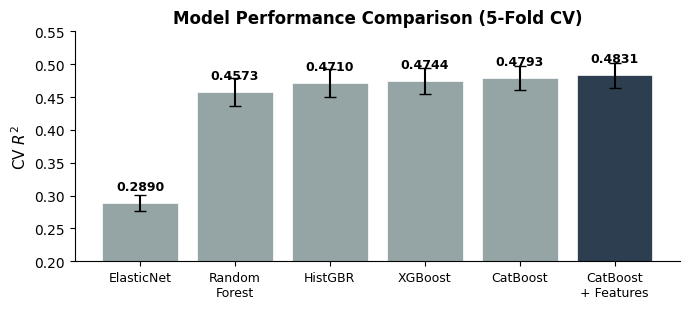

In [33]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ElasticNet', 'Random\nForest', 'HistGBR', 'XGBoost', 'CatBoost', 'CatBoost\n+ Features']
scores = [0.2890, 0.4573, 0.4710, 0.4744, 0.4793, 0.4831]
stds =   [0.0120, 0.0212, 0.0212, 0.0197, 0.0181, 0.0194]

colors = ['#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#2c3e50']

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(models, scores, yerr=stds, capsize=4, color=colors, edgecolor='white', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('CV $R^2$', fontsize=11)
ax.set_ylim(0.2, 0.55)
ax.set_title('Model Performance Comparison (5-Fold CV)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('../report/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()